## Assignment 4: Temporal-Difference Learning

Install and Import Libraries

In [5]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict

Create the CliffWalking Environment
Note: The assignment prompt refers to CliffWalking-v0, but my installed Gymnasium version marks v0 as deprecated. Therefore, I used CliffWalking-v1, which is the current supported Gymnasium version. The environment still has the same 48 states, 4 actions, 4x12 grid structure, start location, goal location, and cliff layout.

In [7]:
env = gym.make("CliffWalking-v1")

n_states = env.observation_space.n
n_actions = env.action_space.n

print("Number of states:", n_states)
print("Number of actions:", n_actions)

Number of states: 48
Number of actions: 4


The CliffWalking environment has a grid with 48 states because the grid is 4 rows by 12 columns. The agent has 4 possible actions: 
0 = Up
1 = Right
2 = Down
3 = Left
Each state will have its own row in the Q-table, and each action will have its own column. The Q-table's numbers each indicate how beneficial it is to perform a particular action from a particular condition.

 Convert State Number to Grid Position

In [8]:
def state_to_position(state, n_cols=12):
    
    row = state // n_cols
    col = state % n_cols
    return row, col

 ε-Greedy Action Selection

In [9]:
def epsilon_greedy_action(Q, state, epsilon, n_actions):
 
    if np.random.random() < epsilon:
        return np.random.choice(n_actions)
    else:
        return np.argmax(Q[state])

 Epsilon Decay Schedule

In [10]:
def get_epsilon(episode, epsilon_start=1.0, epsilon_min=0.05, decay_rate=0.995):
   
    epsilon = epsilon_start * (decay_rate ** episode)
    return max(epsilon_min, epsilon)

Part A: SARSA Implementation

In [11]:
def train_sarsa(
    seed,
    episodes=500,
    alpha=0.5,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.05,
    decay_rate=0.995,
    max_steps=1000
):
    """
    Trains a SARSA agent on CliffWalking-v1.
    
    SARSA performs online TD updates after every env.step().
    """
    
    env = gym.make("CliffWalking-v1")
    env.reset(seed=seed)
    env.action_space.seed(seed)
    np.random.seed(seed)
    
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    
    Q = np.zeros((n_states, n_actions))
    episode_rewards = []
    episode_lengths = []
    
    for episode in range(episodes):
        state, info = env.reset()
        epsilon = get_epsilon(
            episode,
            epsilon_start=epsilon_start,
            epsilon_min=epsilon_min,
            decay_rate=decay_rate
        )
        
        action = epsilon_greedy_action(Q, state, epsilon, n_actions)
        
        total_reward = 0
        steps = 0
        
        for step in range(max_steps):
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            
            total_reward += reward
            steps += 1
            
            if terminated:
                td_target = reward
            else:
                next_action = epsilon_greedy_action(Q, next_state, epsilon, n_actions)
                td_target = reward + gamma * Q[next_state, next_action]
            
            td_error = td_target - Q[state, action]
            Q[state, action] += alpha * td_error
            
            if done:
                break
            
            state = next_state
            action = next_action
        
        episode_rewards.append(total_reward)
        episode_lengths.append(steps)
    
    env.close()
    
    return Q, np.array(episode_rewards), np.array(episode_lengths)

This code trains SARSA one step at a time. After every action, the agent immediately updates its Q-table.
The important part is that SARSA uses the next action that the agent actually chooses. Because that next action may be exploratory, SARSA learns a more cautious strategy.
In CliffWalking, this usually means SARSA avoids walking too close to the cliff because it knows that random exploration could accidentally push it into danger.

Part B: Q-learning Implementation

Q-learning Algorithm

In [15]:
def train_q_learning(
    seed,
    episodes=500,
    alpha=0.5,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.05,
    decay_rate=0.995,
    max_steps=1000
):
    """
    Trains a Q-learning agent on CliffWalking-v1.
    
    Q-learning performs online TD updates after every env.step().
    """
    
    env = gym.make("CliffWalking-v1")
    env.reset(seed=seed)
    env.action_space.seed(seed)
    np.random.seed(seed)
    
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    
    Q = np.zeros((n_states, n_actions))
    episode_rewards = []
    episode_lengths = []
    
    for episode in range(episodes):
        state, info = env.reset()
        epsilon = get_epsilon(
            episode,
            epsilon_start=epsilon_start,
            epsilon_min=epsilon_min,
            decay_rate=decay_rate
        )
        
        total_reward = 0
        steps = 0
        
        for step in range(max_steps):
            action = epsilon_greedy_action(Q, state, epsilon, n_actions)
            
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            
            total_reward += reward
            steps += 1
            
            if terminated:
                td_target = reward
            else:
                td_target = reward + gamma * np.max(Q[next_state])
            
            td_error = td_target - Q[state, action]
            Q[state, action] += alpha * td_error
            
            if done:
                break
            
            state = next_state
        
        episode_rewards.append(total_reward)
        episode_lengths.append(steps)
    
    env.close()
    
    return Q, np.array(episode_rewards), np.array(episode_lengths)

Q-learning differs from SARSA in that it updates after each step. The agent employs the optimal next action based on the Q-table rather than the actual next action. Q-learning becomes more aggressive as a result.
It tries to learn the shortest optimal route. In CliffWalking, that shortest route goes very close to the cliff. That can be good after learning is complete, but risky during training because random exploration can still cause the agent to fall.

Part C: Run Multiple Seeds

Training Both Algorithms Across 30 Seeds

In [16]:
def run_multiple_seeds(
    algorithm,
    seeds,
    episodes=500,
    alpha=0.5,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.05,
    decay_rate=0.995
):
    """
    Runs either SARSA or Q-learning across multiple random seeds.
    """
    
    all_rewards = []
    all_lengths = []
    final_Q_tables = []
    
    for seed in seeds:
        Q, rewards, lengths = algorithm(
            seed=seed,
            episodes=episodes,
            alpha=alpha,
            gamma=gamma,
            epsilon_start=epsilon_start,
            epsilon_min=epsilon_min,
            decay_rate=decay_rate
        )
        
        all_rewards.append(rewards)
        all_lengths.append(lengths)
        final_Q_tables.append(Q)
    
    return np.array(all_rewards), np.array(all_lengths), final_Q_tables

In [17]:
seeds = list(range(30))
episodes = 500

sarsa_rewards, sarsa_lengths, sarsa_Q_tables = run_multiple_seeds(
    train_sarsa,
    seeds=seeds,
    episodes=episodes,
    alpha=0.5,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.05,
    decay_rate=0.995
)

q_rewards, q_lengths, q_Q_tables = run_multiple_seeds(
    train_q_learning,
    seeds=seeds,
    episodes=episodes,
    alpha=0.5,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.05,
    decay_rate=0.995
)

One training run can be lucky or unlucky. To make the results more reliable, we train each algorithm using 30 different random seeds.
A seed controls the randomness. Running 30 seeds helps us see the average behavior instead of judging the algorithm based on only one run.

Part D: Plot Learning Curves with 95% Confidence Intervals
Helper Function for Confidence Intervals:

In [18]:
def mean_and_95_ci(data):
    
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    n = data.shape[0]
    ci = 1.96 * std / np.sqrt(n)
    return mean, ci

In [19]:
sarsa_mean, sarsa_ci = mean_and_95_ci(sarsa_rewards)
q_mean, q_ci = mean_and_95_ci(q_rewards)

Plot Rewards per Episode

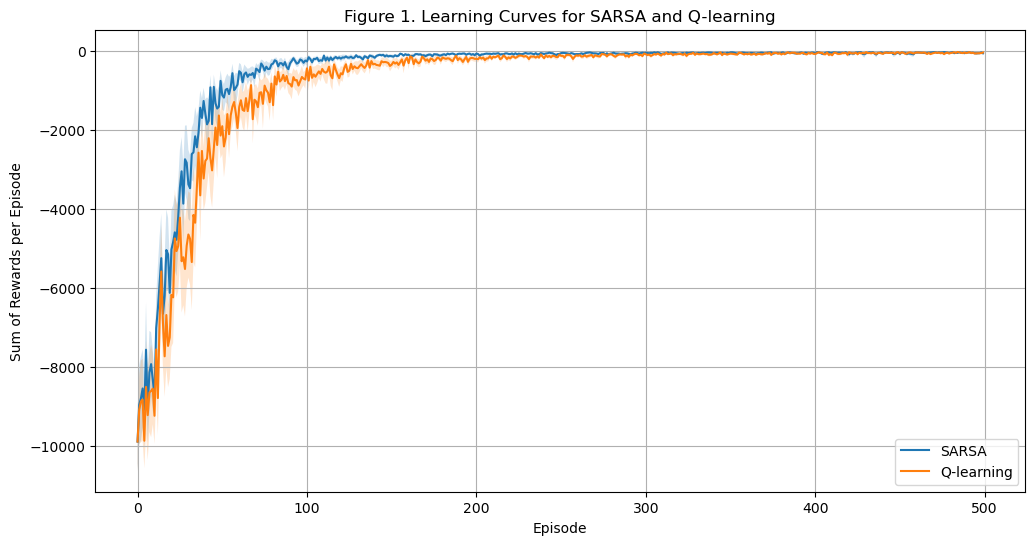

In [20]:
plt.figure(figsize=(12, 6))

episodes_range = np.arange(episodes)

plt.plot(episodes_range, sarsa_mean, label="SARSA")
plt.fill_between(
    episodes_range,
    sarsa_mean - sarsa_ci,
    sarsa_mean + sarsa_ci,
    alpha=0.2
)

plt.plot(episodes_range, q_mean, label="Q-learning")
plt.fill_between(
    episodes_range,
    q_mean - q_ci,
    q_mean + q_ci,
    alpha=0.2
)

plt.xlabel("Episode")
plt.ylabel("Sum of Rewards per Episode")
plt.title("Figure 1. Learning Curves for SARSA and Q-learning")
plt.legend()
plt.grid(True)
plt.show()

Deep Analysis: 

figure 1: The learning curves for SARSA and Q-learning across 500 episodes in the CliffWalking environment. 

Values nearer 0 indicate higher performance since incentives are negative. Due to the agent's extensive exploration and the Q-table's initial ignorance, both methods initially perform badly. This accounts for the extremely high negative rewards in the first few episodes, when the agent probably wanders, chooses ineffective routes, and keeps falling down the cliff.
One important distinction is that SARSA outperforms Q-learning for the majority of the early training phase and improves more quickly. SARSA is an on-policy approach, which is why this occurs. It learns while taking into account the possibility of random exploratory moves, updating using the next action actually selected by its ε-greedy policy. This increases SARSA's caution and promotes a safer path away from the edge in CliffWalking.
Because Q-learning is off-policy, it initially improves more slowly. Assuming future greedy behavior, it updates with the maximum feasible next action. This forces Q-learning to choose the shortest route close to the cliff, which is risky during exploration but ideal while acting avariciously. A significant penalty may be imposed on the agent if a random action takes place close to the cliff. Both algorithms learn effective behavior toward the end, since both curves settle close to zero; nevertheless, SARSA shows safer and more stable learning during training.


Part E: Smooth the Learning Curves
Moving Average Function: 

In [21]:
def moving_average(data, window=20):
     
    return np.convolve(data, np.ones(window) / window, mode="valid")

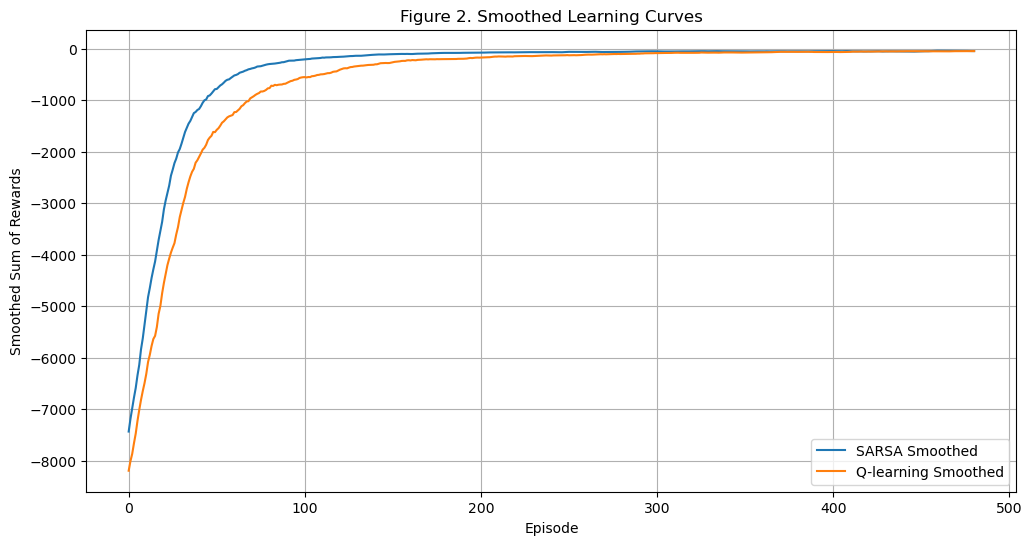

In [22]:
window = 20

sarsa_smooth = moving_average(sarsa_mean, window)
q_smooth = moving_average(q_mean, window)

plt.figure(figsize=(12, 6))

plt.plot(sarsa_smooth, label="SARSA Smoothed")
plt.plot(q_smooth, label="Q-learning Smoothed")

plt.xlabel("Episode")
plt.ylabel("Smoothed Sum of Rewards")
plt.title("Figure 2. Smoothed Learning Curves")
plt.legend()
plt.grid(True)
plt.show()

Figure 2 smooths the learning curves so the overall trend is easier to see. 
Here, i just wanted to show a smoothed plot to make it clearer. 

Part F: Value Function Heatmaps
Convert Q-table to State Value Function: 

In [23]:
def get_value_function(Q):
   
    return np.max(Q, axis=1)

In [24]:
final_sarsa_Q = sarsa_Q_tables[-1]
final_q_Q = q_Q_tables[-1]

sarsa_values = get_value_function(final_sarsa_Q).reshape(4, 12)
q_values = get_value_function(final_q_Q).reshape(4, 12)

Plot Heatmaps

In [25]:
def plot_value_heatmap(values, title):
    
    plt.figure(figsize=(12, 4))
    plt.imshow(values)
    plt.colorbar(label="State Value")
    plt.title(title)
    plt.xlabel("Column")
    plt.ylabel("Row")
    
    for row in range(values.shape[0]):
        for col in range(values.shape[1]):
            plt.text(
                col,
                row,
                f"{values[row, col]:.1f}",
                ha="center",
                va="center"
            )
    
    plt.show()

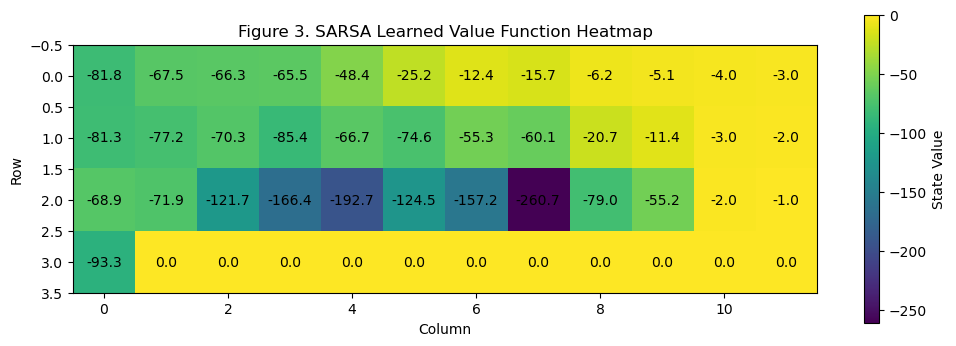

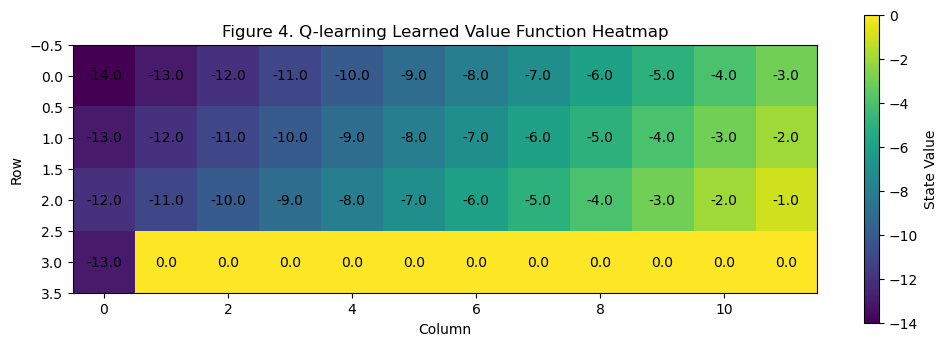

In [26]:
plot_value_heatmap(
    sarsa_values,
    "Figure 3. SARSA Learned Value Function Heatmap"
)

plot_value_heatmap(
    q_values,
    "Figure 4. Q-learning Learned Value Function Heatmap"
)

Figures 3 and 4 compare the learned value functions for SARSA and Q-learning after training in the CliffWalking environment.

Each number represents the best estimated value for that state. Because the environment gives negative rewards, values closer to 0 are better, while very negative values suggest danger, inefficiency, or a higher chance of receiving a large penalty.

SARSA generates a number of extremely negative values in Figure 3, particularly in the center and lower-middle regions of the grid. This demonstrates that SARSA developed a more circumspect perspective on the surroundings. SARSA updates its Q-values using the same ε-greedy policy that it really uses during training because it is an on-policy approach. As a result, SARSA takes into account the potential for random exploratory acts. SARSA assigns a significantly lower score to a condition that is close to a hazardous location where a single mistake might result in the cliff.

Figure 4 shows a smoother Q-learning value function. The values move steadily from about -14 near the start toward -1 near the goal. This reflects Q-learning’s off-policy nature. It learns as if the agent will always choose the best future action. Overall, SARSA reflects risk-aware learning, while Q-learning reflects the shortest optimal greedy path.


Part G: Learned Policy Arrows
Plot Learned Q-values as Arrows:

In [30]:
from matplotlib.colors import ListedColormap

def plot_policy_arrows(Q, title):
    """
    Plots the greedy policy from a Q-table as arrows on the CliffWalking grid.
    """
    
    action_symbols = {
        0: "↑",
        1: "→",
        2: "↓",
        3: "←"
    }
    
    grid = np.full((4, 12), "", dtype=object)
    
    for state in range(Q.shape[0]):
        row, col = state_to_position(state)
        best_action = np.argmax(Q[state])
        grid[row, col] = action_symbols[best_action]
    
    # Mark start, goal, and cliff
    grid[3, 0] = "S"
    grid[3, 11] = "G"
    for col in range(1, 11):
        grid[3, col] = "C"
    
    plt.figure(figsize=(12, 4))


    yellow_cmap = ListedColormap(["yellow"])
    plt.imshow(np.zeros((4, 12)), cmap=yellow_cmap)

    plt.title(title)
    plt.xlabel("Column")
    plt.ylabel("Row")
    
    for row in range(4):
        for col in range(12):
            plt.text(
                col,
                row,
                grid[row, col],
                ha="center",
                va="center",
                fontsize=16,
                color="black"
            )
    
    plt.xticks(range(12))
    plt.yticks(range(4))
    plt.grid(True)
    plt.show()

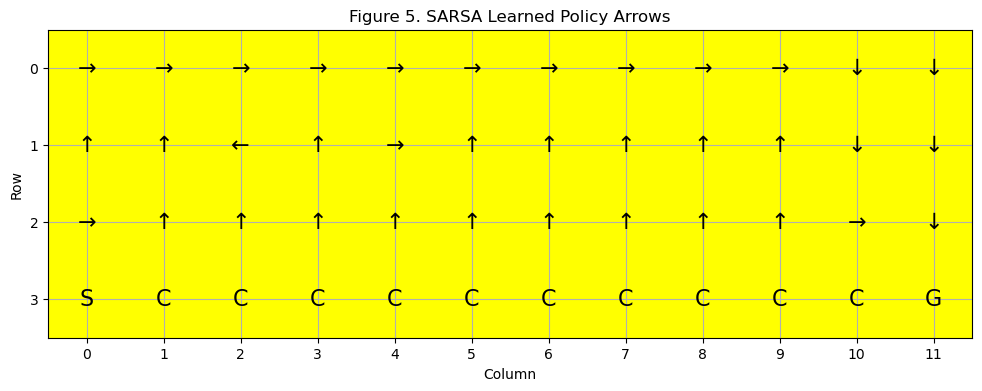

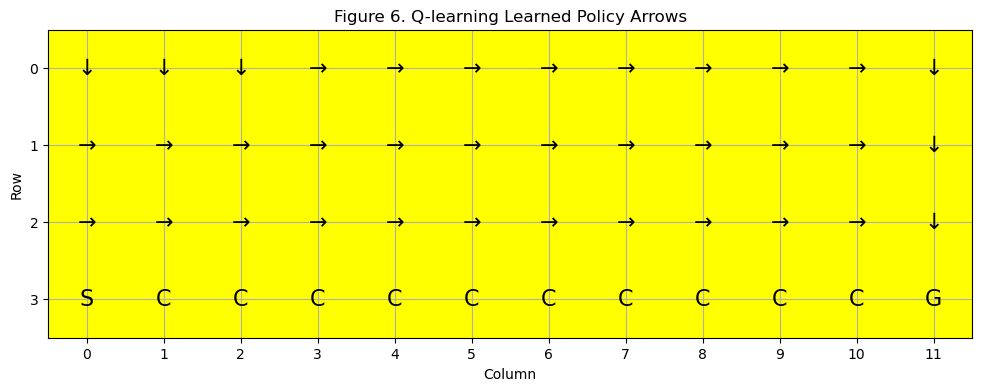

In [31]:
plot_policy_arrows(
    final_sarsa_Q,
    "Figure 5. SARSA Learned Policy Arrows"
)

plot_policy_arrows(
    final_q_Q,
    "Figure 6. Q-learning Learned Policy Arrows"
)

In Figures 5 and 6 we can see that the learnt greedy policies for SARSA and Q-learning are displayed using arrows 

The action with the greatest learnt Q-value for that state is represented by each arrow. The agent must figure out how to go to the objective without going over the cliff because the start state, cliff cells, and goal state are located in the bottom row.

SARSA's arrows in Figure 5 indicate a less direct and more careful approach. Particularly near the center of the grid, several arrows lead upward and away from the lower cliff region. This implies that SARSA acquired the ability to steer clear of conditions in which exploration would unintentionally force the agent down the cliff. Because SARSA is on-policy, its policy matches actual exploration risk because it learns using the same ε-greedy behavior that it exhibits during training.

The arrows of Q-learning provide a more straightforward moving pattern toward the objective in Figure 6. Numerous arrows point down close to the goal after pointing straight across the grid. Because it learns the optimum greedy path on the assumption that the agent would select the best course of action in the future, this replicates the off-policy behavior of Q-learning.

Overall, Q-learning's arrows indicate a more ideal but risky path that may perform well after learning but may suffer during exploration, whereas SARSA's arrows indicate a safer path that avoids danger.


Part H: Sample Trajectories
Generate a Greedy Trajectory:

In [35]:
def generate_greedy_trajectory(Q, max_steps=100):

    
    env = gym.make("CliffWalking-v1")
    state, info = env.reset()
    
    trajectory = [state]
    total_reward = 0
    
    for step in range(max_steps):
        action = np.argmax(Q[state])
        next_state, reward, terminated, truncated, info = env.step(action)
        
        trajectory.append(next_state)
        total_reward += reward
        
        if terminated or truncated:
            break
        
        state = next_state
    
    env.close()
    
    return trajectory, total_reward

Plot Sample Trajectory

In [36]:
def plot_trajectory(trajectory, title):
    
    
    grid = np.zeros((4, 12))
    
    plt.figure(figsize=(12, 4))
    plt.imshow(grid)
    
    # Mark cliff
    for col in range(1, 11):
        plt.text(col, 3, "C", ha="center", va="center", fontsize=14)
    
    # Mark start and goal
    plt.text(0, 3, "S", ha="center", va="center", fontsize=14)
    plt.text(11, 3, "G", ha="center", va="center", fontsize=14)
    
    rows = []
    cols = []
    
    for state in trajectory:
        row, col = state_to_position(state)
        rows.append(row)
        cols.append(col)
    
    plt.plot(cols, rows, marker="o")
    
    for i, state in enumerate(trajectory):
        row, col = state_to_position(state)
        plt.text(col, row - 0.15, str(i), ha="center", fontsize=8)
    
    plt.title(title)
    plt.xlabel("Column")
    plt.ylabel("Row")
    plt.xticks(range(12))
    plt.yticks(range(4))
    plt.grid(True)
    plt.show()

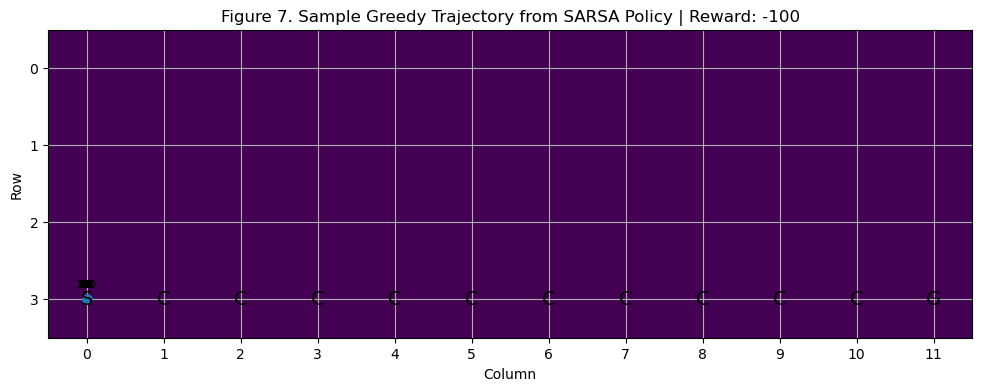

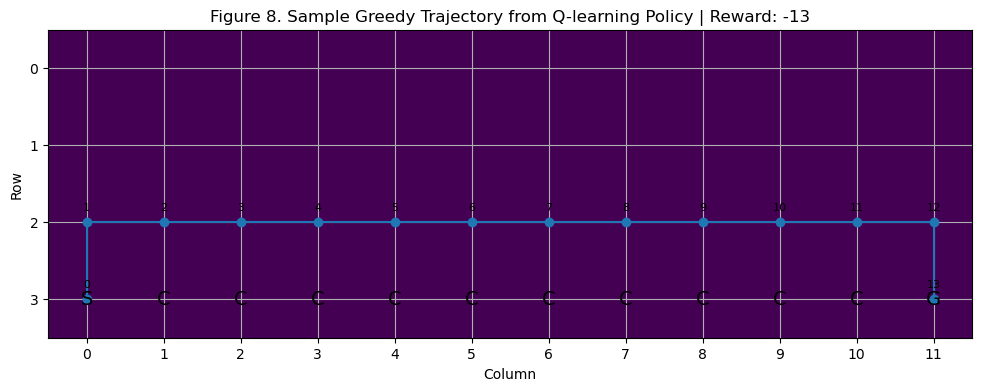

In [37]:
sarsa_trajectory, sarsa_traj_reward = generate_greedy_trajectory(final_sarsa_Q)
q_trajectory, q_traj_reward = generate_greedy_trajectory(final_q_Q)

plot_trajectory(
    sarsa_trajectory,
    f"Figure 7. Sample Greedy Trajectory from SARSA Policy | Reward: {sarsa_traj_reward}"
)

plot_trajectory(
    q_trajectory,
    f"Figure 8. Sample Greedy Trajectory from Q-learning Policy | Reward: {q_traj_reward}"
)

Figures 7 and 8 show sample greedy trajectories generated from the learned SARSA and Q-learning policies.

Because they convert the learnt Q-values into real grid behavior, these graphs are very helpful. The SARSA trajectory in Figure 7 remains close to the beginning and makes little discernible progress toward the objective. The overall reward of -100 strongly implies that the strategy stayed trapped in a brief loop close to the beginning area rather than achieving the target inside the step limit. A reward of -100 corresponds to taking 100 ineffective steps as each regular step yields a reward of -1. This suggests that SARSA generated an extremely conservative or poorly converged strategy for this specific learnt Q-table.

In contrast, Figure 8 shows a much clearer and more successful Q-learning trajectory. The agent moves up once, travels right across the row above the cliff, and then moves down into the goal. The total reward is -13, which matches the expected shortest safe path length. This confirms that Q-learning learned the near-optimal greedy route.


Part I: Experiment with Different Alpha Values and Epsilon Decay

In [38]:
experiment_settings = [
    {"alpha": 0.1, "decay_rate": 0.995},
    {"alpha": 0.5, "decay_rate": 0.995},
    {"alpha": 0.9, "decay_rate": 0.995},
    {"alpha": 0.5, "decay_rate": 0.990},
    {"alpha": 0.5, "decay_rate": 0.999},
]

experiment_results = []

for setting in experiment_settings:
    alpha = setting["alpha"]
    decay_rate = setting["decay_rate"]
    
    sarsa_rewards_exp, sarsa_lengths_exp, _ = run_multiple_seeds(
        train_sarsa,
        seeds=seeds,
        episodes=episodes,
        alpha=alpha,
        gamma=1.0,
        epsilon_start=1.0,
        epsilon_min=0.05,
        decay_rate=decay_rate
    )
    
    q_rewards_exp, q_lengths_exp, _ = run_multiple_seeds(
        train_q_learning,
        seeds=seeds,
        episodes=episodes,
        alpha=alpha,
        gamma=1.0,
        epsilon_start=1.0,
        epsilon_min=0.05,
        decay_rate=decay_rate
    )
    
    experiment_results.append({
        "Algorithm": "SARSA",
        "Alpha": alpha,
        "Decay Rate": decay_rate,
        "Final 50-Episode Avg Reward": np.mean(sarsa_rewards_exp[:, -50:]),
        "Final 50-Episode Avg Length": np.mean(sarsa_lengths_exp[:, -50:]),
        "Learning Speed Avg Reward Episodes 1-100": np.mean(sarsa_rewards_exp[:, :100])
    })
    
    experiment_results.append({
        "Algorithm": "Q-learning",
        "Alpha": alpha,
        "Decay Rate": decay_rate,
        "Final 50-Episode Avg Reward": np.mean(q_rewards_exp[:, -50:]),
        "Final 50-Episode Avg Length": np.mean(q_lengths_exp[:, -50:]),
        "Learning Speed Avg Reward Episodes 1-100": np.mean(q_rewards_exp[:, :100])
    })

results_df = pd.DataFrame(experiment_results)
results_df

,Algorithm,Alpha,Decay Rate,Final 50-Episode Avg Reward,Final 50-Episode Avg Length,Learning Speed Avg Reward Episodes 1-100
0,SARSA,0.1,0.995,-20.863333,18.949333,-2222.120333
1,Q-learning,0.1,0.995,-46.154000,16.520000,-3560.380000
2,SARSA,0.5,0.995,-42.416000,36.740000,-2505.983000
3,Q-learning,0.5,0.995,-45.748667,16.378667,-3366.985000
4,SARSA,0.9,0.995,-203.127333,122.475333,-4424.505000
5,Q-learning,0.9,0.995,-41.808000,16.200000,-3084.541667
6,SARSA,0.5,0.990,-32.518667,29.812667,-1399.821333
7,Q-learning,0.5,0.990,-32.038000,14.812000,-1967.060333
8,SARSA,0.5,0.999,-248.976667,84.240667,-7084.041667
9,Q-learning,0.5,0.999,-452.800000,69.208000,-7758.193667


The experiment table shows how changing the learning rate (α) and epsilon decay rate affects SARSA and Q-learning in CliffWalking.

Particularly for SARSA, it is evident that moderate or modest α values perform significantly better than very big ones. With α = 0.1 and decay = 0.995, SARSA had the greatest final performance and the highest final 50-episode average reward (-20.86). This implies that a lower learning rate helped SARSA develop a safer policy without responding to noisy encounters and provided more reliable updates.

Q-learning’s best final result appears with α = 0.5 and decay = 0.990 (-32.04), closely followed by its other moderate settings. This indicates that Q-learning handled larger learning rates better than SARSA and remained fairly efficient, with shorter final episode lengths around 15–16 steps, which is consistent with learning a more direct path.
The worst results occur when exploration decays too slowly (decay = 0.999). Both algorithms perform badly there, especially Q-learning (-452.80 final reward), showing that prolonged exploration keeps causing costly mistakes. SARSA also collapses with α = 0.9, where its final reward and episode length become very poor, meaning overly aggressive updates hurt convergence.


Create a Clean Comparison Table

In [39]:
comparison_table = results_df.sort_values(
    by=["Final 50-Episode Avg Reward"],
    ascending=False
)

comparison_table

,Algorithm,Alpha,Decay Rate,Final 50-Episode Avg Reward,Final 50-Episode Avg Length,Learning Speed Avg Reward Episodes 1-100
0,SARSA,0.1,0.995,-20.863333,18.949333,-2222.120333
7,Q-learning,0.5,0.990,-32.038000,14.812000,-1967.060333
6,SARSA,0.5,0.990,-32.518667,29.812667,-1399.821333
5,Q-learning,0.9,0.995,-41.808000,16.200000,-3084.541667
2,SARSA,0.5,0.995,-42.416000,36.740000,-2505.983000
3,Q-learning,0.5,0.995,-45.748667,16.378667,-3366.985000
1,Q-learning,0.1,0.995,-46.154000,16.520000,-3560.380000
4,SARSA,0.9,0.995,-203.127333,122.475333,-4424.505000
8,SARSA,0.5,0.999,-248.976667,84.240667,-7084.041667
9,Q-learning,0.5,0.999,-452.800000,69.208000,-7758.193667


The rating is considerably simpler to understand because to the clear comparison table.
SARSA with α = 0.1 and decay = 0.995 has the greatest final 50-episode average reward (-20.86), making it the optimal configuration overall. This implies that fewer, more reliable updates are advantageous to SARSA. With a final reward of -32.04 and a lower average episode duration (14.81), the strongest Q-learning setting is α = 0.5 and decay = 0.990, indicating that Q-learning prefers to learn more direct pathways. Decay = 0.999 is the weakest value, where exploration is still too high. In general, the most dependable outcomes are obtained with modest learning and quicker epsilon decay.

Part J: Final Comparison Table for Main SARSA vs. Q-learning Run

In [41]:
def episodes_to_threshold(rewards_array, threshold=-50, window=20):
    
    mean_rewards = np.mean(rewards_array, axis=0)
    
    for episode in range(window, len(mean_rewards)):
        recent_average = np.mean(mean_rewards[episode-window:episode])
        if recent_average >= threshold:
            return episode
    
    return np.nan

In [42]:
final_comparison_table = pd.DataFrame({
    "Algorithm": ["SARSA", "Q-learning"],
    
    "Final Performance: Avg Reward Last 50 Episodes": [
        np.mean(sarsa_rewards[:, -50:]),
        np.mean(q_rewards[:, -50:])
    ],
    
    "Learning Speed: Avg Reward First 100 Episodes": [
        np.mean(sarsa_rewards[:, :100]),
        np.mean(q_rewards[:, :100])
    ],
    
    "Sample Efficiency: Episodes to Reach -50 Avg Reward": [
        episodes_to_threshold(sarsa_rewards, threshold=-50, window=20),
        episodes_to_threshold(q_rewards, threshold=-50, window=20)
    ],
    
    "Final Avg Episode Length Last 50 Episodes": [
        np.mean(sarsa_lengths[:, -50:]),
        np.mean(q_lengths[:, -50:])
    ],
    
    "Policy Behavior": [
        "Safer path; accounts for exploration risk",
        "Shorter optimal path; riskier during exploration"
    ]
})

final_comparison_table

,Algorithm,Final Performance: Avg Reward Last 50 Episodes,Learning Speed: Avg Reward First 100 Episodes,Sample Efficiency: Episodes to Reach -50 Avg Reward,Final Avg Episode Length Last 50 Episodes,Policy Behavior
0,SARSA,-42.416000,-2505.983,308,36.740000,Safer path; accounts for exploration risk
1,Q-learning,-45.748667,-3366.985,444,16.378667,Shorter optimal path; riskier during exploration


The final comparison table shows us the final performance, learning speed, sample efficiency, episode duration, and policy behavior are used to describe SARSA and Q-learning.

Compared to Q-learning (-45.75), SARSA offers a little higher final 50-episode average reward (-42.42). The value nearer 0 is preferable as CliffWalking incentives are negative. This indicates that SARSA did somewhat better under these conditions at the conclusion of training.

Additionally, SARSA demonstrates superior early learning. In contrast to Q-learning's -3366.99, its first 100-episode average reward is -2505.98. This implies that during early exploration, SARSA faced fewer severe consequences. This pattern is supported by the sample efficiency result: Q-learning required 444 episodes to meet the -50 average reward threshold, whereas SARSA did it in 308 episodes. As a result, SARSA discovered a practical policy with fewer occurrences.

But compared to SARSA (36.74), Q-learning's final episode duration is significantly less (16.38). This demonstrates that Q-learning discovered a more straightforward path to the objective. Because SARSA avoids dangerous cliff-adjacent situations, its longer journey reflects its safer behavior.